In [29]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, random_split
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

def train_tensor4_reconstruction_gd(p: int,
                                    H: int,
                                    sigma2: float,
                                    T: float,
                                    num_epochs: int,
                                    batch_size: int,
                                    t_max=None,
                                    no_target: bool = True,
                                    device: str = "cuda:0",
                                    seed: int | None = None):
    """
    Analytic full-batch GD for order-4 tensor reconstruction with shared CP factors.

    Objective:
        pred[i,j,k,l] = sum_h u[h,i] u[h,j] u[h,k] u[h,l]

    Let G = u @ u.T, shape H x H.

    If no_target=True:
        L = 1/2 sum_{a,b} G[a,b]^4
        grad = 4 * G^{circ 3} @ u

    If no_target=False, target is the diagonal order-4 identity:
        L = 1/2 sum_{a,b} G[a,b]^4 - sum_{h,i} u[h,i]^4 + p/2
        grad = 4 * G^{circ 3} @ u - 4 * u^{circ 3}
    """

    # Set seed if requested
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # Time grid
    if t_max is None:
        t_max = num_epochs

    t_arr, tau = np.linspace(0, t_max, num_epochs + 1, retstep=True)
    tau = t_arr[1] - t_arr[0]

    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    sigma = float(sigma2) ** 0.5

    # Parameter tensor
    u = torch.randn(H, p, device=dev) * sigma

    lr = abs(tau / T)
    step_sign = 1.0 if tau < 0 else -1.0

    epoch_loss_hist = []

    # Internal memory guard:
    # for ordinary experiment sizes, use full H x H Gram;
    # for very large H, compute gradient in chunks.
    max_gram_entries = max(int(batch_size), 100_000_000)

    with torch.no_grad():
        for epoch in tqdm(range(1, num_epochs + 1)):
            # Fast path: materialize full Gram matrix
            if H * H <= max_gram_entries:
                G = u @ u.T                         # H x H
                G3 = G * G * G                      # elementwise cube

                loss = 0.5 * torch.sum(G3 * G)      # 1/2 sum G^4
                grad = 4.0 * (G3 @ u)

            # Memory-safe path: chunk rows of G
            else:
                chunk_rows = max(1, max_gram_entries // H)
                loss = u.new_tensor(0.0)
                grad = torch.empty_like(u)

                for s in range(0, H, chunk_rows):
                    e = min(s + chunk_rows, H)

                    G_chunk = u[s:e] @ u.T
                    G3_chunk = G_chunk * G_chunk * G_chunk

                    loss = loss + 0.5 * torch.sum(G3_chunk * G_chunk)
                    grad[s:e] = 4.0 * (G3_chunk @ u)

            if not no_target:
                u2 = u * u
                u3 = u2 * u
                u4 = u2 * u2

                loss = loss - torch.sum(u4) + 0.5 * p
                grad = grad - 4.0 * u3

            epoch_loss = float(loss.item())

            # Manual SGD step
            u.add_(grad, alpha=step_sign * lr)

            epoch_loss_hist.append(epoch_loss)

            if epoch_loss_hist[0] != 0 and epoch_loss / epoch_loss_hist[0] > 1.5:
                break

    return u.detach().cpu(), np.array(epoch_loss_hist), t_arr[:len(epoch_loss_hist)]

In [6]:
import mpmath as mp

def erfcx_custom(t):
    """Scaled complementary error function erfcx(t) = exp(t^2) * erfc(t)."""
    t = mp.mpf(t)
    if t < 20:  # safe region
        return mp.e**(t*t) * mp.erfc(t)
    # asymptotic expansion for large t
    invt = 1/t
    invt2 = invt*invt
    series = 1 + 0.5*invt2 + 0.75*invt2**2 + 1.875*invt2**3
    return series / (mp.sqrt(mp.pi) * t)

def integral_F3(dps=80, cutoff=8):
    """
    Compute I = ∫_0^{-∞} F(x)^3 dx using substitution:
        I = -∫_0^∞ t^3 [1 - t*sqrt(pi)*erfcx(t)]^3 dt
    with tail correction.
    """
    mp.mp.dps = dps
    sqrtpi = mp.sqrt(mp.pi)

    def g(t):
        return 1 - t*sqrtpi*erfcx_custom(t)

    def integrand(t):
        return - (t**3) * (g(t)**3)

    I_num = mp.quad(integrand, [0, cutoff])

    # tail correction: ~ ∫_cutoff^∞ (1/8) t^{-3} dt
    tail = mp.mpf(1) / (16 * cutoff**2)
    I = I_num + tail

    # quick stability check with different cutoff
    cutoff2 = cutoff * 1.25
    I_num2 = mp.quad(integrand, [0, cutoff2])
    tail2 = mp.mpf(1) / (16 * cutoff2**2)
    I2 = I_num2 + tail2
    err_est = abs(I - I2)

    return I, err_est

In [7]:
I, err = integral_F3(dps=100, cutoff=100)
print("Integral I ≈", mp.nstr(I, 20))
print("Rough error ≲", mp.nstr(err, 6))
H_p2 = 1
theta = 1 + 3*H_p2
p3sigma4crit = np.float64(-1/16/theta/I)
print(p3sigma4crit)

Integral I ≈ -0.02976615563721900203
Rough error ≲ 5.3955e-7
0.5249250252680536


In [8]:
from functools import lru_cache
from scipy.integrate import quad, solve_ivp
from scipy.special import erfcx

# ------------------------ Parameter integrals ------------------------

# Small-|a| series accelerators (avoid cancellation when |a| ~ 0)
# F(a) = sum_{n>=0} (4a)^n * (2n+1)! / n!
# J3(a)= sum_{n>=0} (4a)^n * (2n+3)! / n!
def _series_F(a, tol=1e-14, nmax=20):
    a = float(a)
    s = 0.0
    term = 1.0  # n=0: (4a)^0*(1)!/0! = 1
    s += term
    four_a = 4.0 * a
    for n in range(1, nmax+1):
        # term_n / term_{n-1} = (4a) * (2n+1)!/n! * (n-1)!/(2n-1)! = (4a)*(2n)(2n+1)/n
        # but we can compute directly to avoid accum error:
        term *= four_a
        term *= (2*n)*(2*n+1)/n
        s_new = s + term
        if abs(term) <= tol * max(1.0, abs(s_new)):
            s = s_new
            break
        s = s_new
    return s

def _series_J3(a, tol=1e-14, nmax=20):
    a = float(a)
    s = 0.0
    # n=0: (4a)^0 * (3)! / 0! = 6
    term = 6.0
    s += term
    four_a = 4.0 * a
    for n in range(1, nmax+1):
        # term_n / term_{n-1} = (4a) * (2n+3)!/n! * (n-1)!/(2n+1)! = (4a)*(2n+2)(2n+3)/n
        term *= four_a
        term *= (2*n+2)*(2*n+3)/n
        s_new = s + term
        if abs(term) <= tol * max(1.0, abs(s_new)):
            s = s_new
            break
        s = s_new
    return s

@lru_cache(maxsize=None)
def F_of_a(a):
    """
    Stable closed form for F(a) for a <= 0, with a small-|a| series near 0.
    F(a) = -1/(8a) + (1/(32a)) * sqrt(pi/(-a)) * erfcx(1/(4*sqrt(-a))),   a<0
    and F(0) = 1.
    """
    a = float(a)
    if a > 0.0:
        raise ValueError(f"F(a) diverges for a>0 (a={a}).")
    if a == 0.0:
        return 1.0
    if abs(a) < 1e-8:
        return _series_F(a)

    t = 1.0/(4.0*np.sqrt(-a))
    # Numerically stable: uses erfcx, not exp(...) * erfc(...)
    return -1.0/(8.0*a) + (1.0/(32.0*a)) * np.sqrt(np.pi/(-a)) * erfcx(t)

@lru_cache(maxsize=None)
def J3_of_a(a):
    """
    Robust evaluation of J3(a) = ∫_0^∞ e^{4 a u^2 - u} u^3 du for a <= 0.
    Uses a small-|a| series near 0 and quad otherwise.
    """
    a = float(a)
    if a > 0.0:
        raise ValueError(f"J3(a) diverges for a>0 (a={a}).")
    if a == 0.0:
        return 6.0
    if abs(a) < 1e-8:
        return _series_J3(a)

    integrand = lambda u: np.exp(4.0*a*u*u - u) * (u**3)
    val, err = quad(integrand, 0.0, np.inf, epsabs=1e-11, epsrel=1e-11, limit=200)
    return val

# ------------------------ ODE for ψ and v=ψ' ------------------------

def _make_rhs(p, sigma2,theta):
    sigma = np.sqrt(sigma2)
    def rhs(x, y):
        psi, v = y
        a = sigma2 * psi  # parameter for F
        if a > 0.0:
            # Not defined: push back / signal by clipping to a->0-
            # You can also raise here, but clipping is safer inside solver.
            a = -0.0
        Fa = F_of_a(a)
        dv = -8.0 * theta* (p**3) * (sigma**6) * (v**4) * (Fa**3)
        return [v, dv]
    return rhs

def _solve_psi_on_grid(p, sigma2, theta, xs, x0=0.0):
    """
    Solve ψ' = v, v' = -8 p^3 σ^6 v^4 F(σ^2 ψ)^3 on an xs-grid.
    Returns arrays ψ(xs), v(xs). Uses dense_output interpolation.
    """
    xs = np.asarray(xs, dtype=float)
    rhs = _make_rhs(p, sigma2, theta)
    psi0, v0 = 0.0, 1.0

    x_min, x_max = xs.min(), xs.max()

    # Integrate downwards if needed
    sol_down = None
    if x_min < x0:
        sol_down = solve_ivp(rhs, (x0, x_min), [psi0, v0],
                             dense_output=True, rtol=1e-8, atol=1e-10, max_step=0.1)
        if not sol_down.success:
            raise RuntimeError(f"ODE integration failed (down): {sol_down.message}")

    # Integrate upwards if needed
    sol_up = None
    if x_max > x0:
        sol_up = solve_ivp(rhs, (x0, x_max), [psi0, v0],
                           dense_output=True, rtol=1e-8, atol=1e-10, max_step=0.1)
        if not sol_up.success:
            raise RuntimeError(f"ODE integration failed (up): {sol_up.message}")

    psi = np.empty_like(xs)
    v   = np.empty_like(xs)
    for i, x in enumerate(xs):
        if x <= x0 and sol_down is not None:
            z = sol_down.sol(x)
        elif x >= x0 and sol_up is not None:
            z = sol_up.sol(x)
        else:
            # x == x0
            z = np.array([psi0, v0])
        psi[i], v[i] = float(z[0]), float(z[1])
    return psi, v

# ------------------------ Main: g(x) ------------------------

def g_of_x_y(x,y,p,sigma2, require_x_ge_0=True, return_parts=False):
    """
    Compute g(x) = 0.5*z2(-x)^4 - z4(-x), with
      z2(-x) = p σ^2 φ(-x) F(σ^2 ψ(-x)),
      z4(-x) = (p σ^4 φ(-x)^2 / 2) * J3(σ^2 ψ(-x)),
    where ψ' = φ, φ' = -8 (p σ^2 φ F(σ^2 ψ))^3 φ.

    Parameters
    ----------
    x : float or array-like
        Points at which to evaluate g(x). **Recommended: x >= 0**.
    p : float
    sigma2 : float
        σ^2 parameter (nonnegative).
    require_x_ge_0 : bool, default True
        If True, raises if any x<0 (since -x>0 leads to a>0 → divergences).
        If False, the solver still tries but will clip a to 0 when it drifts >0.
    return_parts : bool, default False
        If True, also returns (z2_vals, z4_vals, psi_vals, phi_vals, a_vals) in addition to g.

    Returns
    -------
    g_vals : ndarray
        Values of g(x) at the requested x.
    (optional) z2, z4, psi(-x), phi(-x), a(-x)
    """
    theta = 1 + 3*y
    
    x = np.atleast_1d(np.asarray(x, dtype=float))

    if require_x_ge_0 and np.any(x < 0):
        raise ValueError("g_of_x: please provide x >= 0 (so that -x <= 0 and the parameter integrals remain finite).")

    # We need ψ and φ at -x
    xm = -x
    psi_vals, phi_vals = _solve_psi_on_grid(p, sigma2,theta, xm, x0=0.0)

    a_vals = sigma2 * psi_vals  # parameter a = σ^2 ψ(-x); should satisfy a ≤ 0 for well-posedness
    # Evaluate F and J3
    F_vals  = np.array([F_of_a(a)  for a in a_vals])
    J3_vals = np.array([J3_of_a(a) for a in a_vals])

    # z2(-x), z4(-x)
    z2_vals = p * sigma2 * phi_vals * F_vals
    z4_vals = 0.5 * p * (sigma2**2) * (phi_vals**2) * J3_vals

    g_vals = (0.5 * z2_vals**4 * theta - z4_vals)*y

    if g_vals.size == 1:
        g_vals = g_vals.item()
    if return_parts:
        return g_vals, z2_vals, z4_vals, psi_vals, phi_vals, a_vals
    return g_vals

def L_ascent(t,H,p,sigma2,T):
    return p/2 + p**2*g_of_x_y(-t/T,H/p**2,p,sigma2)

# Experiments for phase diagram in $\theta-\rho$

In [55]:
%%time
rho_arr = np.logspace(np.log10(0.02),np.log10(2.5),16)
theta_arr = np.logspace(np.log10(1.1),np.log10(100.1),16)

loss_hist_theta_rho = []
t_arr_hist_theta_rho = []
p=64
t_max_neg = -0.3
num_iters_neg = 200
batch_size = int(2**18)
for theta in theta_arr:
    H = int((theta-1)/3*p**2)
    loss_hist_rho = []
    t_arr_hist_rho = []
    for rho in rho_arr:
        sigma2 = (rho/p**3)**0.5
        T = sigma2
        loss_seeds = []
        t_arr_seeds = []
        for seed in range(10):
            u,loss_hist,t_arr = train_tensor4_reconstruction_gd(p,H,sigma2,T,num_iters_neg,batch_size,t_max_neg,no_target=False,seed=seed)
            t_arr_seeds.append(t_arr)
            loss_seeds.append(loss_hist)
        loss_hist_rho.append(loss_seeds)
        t_arr_hist_rho.append(t_arr_seeds)
    loss_hist_theta_rho.append(loss_hist_rho)
    t_arr_hist_theta_rho.append(t_arr_hist_rho)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 4h 49min 58s, sys: 15min 48s, total: 5h 5min 46s
Wall time: 5h 5min 19s


In [56]:
func_arr = np.zeros((16,16))
for i,theta in enumerate(theta_arr):
    for j,rho in enumerate(rho_arr):
        count = 0
        for seed in range(10):
            if loss_hist_theta_rho[i][j][seed][-1]/loss_hist_theta_rho[i][j][seed][0]>1.5:
                count+=1
        func_arr[i,j] = count/10

In [57]:
I, err = integral_F3(dps=100, cutoff=100)
rho_crit = np.float64(-1/16/theta_arr/I)

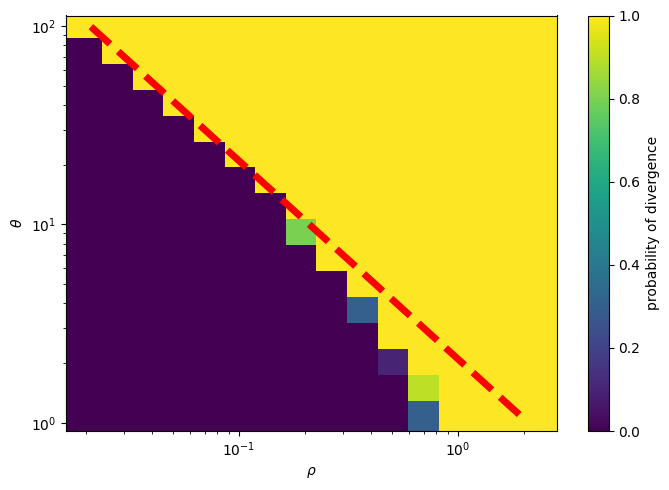

In [58]:
# Create meshgrid for plotting
RHO, THETA = np.meshgrid(rho_arr, theta_arr)

fig, ax = plt.subplots(figsize=(7, 5))

# 2D color plot
c = ax.pcolormesh(
    RHO,
    THETA,
    func_arr,
    shading='auto'
)
ax.plot(rho_crit,theta_arr,color='red',linestyle='--',linewidth=5)

# Log scales on both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Labels
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'$\theta$')

# Colorbar
cb = fig.colorbar(c, ax=ax)
cb.set_label('probability of divergence')

plt.tight_layout()
plt.show()

In [59]:
import pickle

# Save
with open("loss_hist_theta_rho.pkl", "wb") as f:
    pickle.dump(loss_hist_theta_rho, f)
with open("t_arr_hist_theta_rho.pkl", "wb") as f:
    pickle.dump(t_arr_hist_theta_rho, f)

# Specific plots of the loss evolution

In [42]:
I, err = integral_F3(dps=100, cutoff=100)
print("Integral I ≈", mp.nstr(I, 20))
print("Rough error ≲", mp.nstr(err, 6))
H_p2 = 3
theta = 1 + 3*H_p2
p3sigma4crit = np.float64(-1/16/theta/I)
print(p3sigma4crit)

Integral I ≈ -0.02976615563721900203
Rough error ≲ 5.3955e-7
0.20997001010722144


In [43]:
p = 256
H = int(H_p2*p**2)
rho_list = [0.5,2.0]
t_max_list = [0.05,0.011]

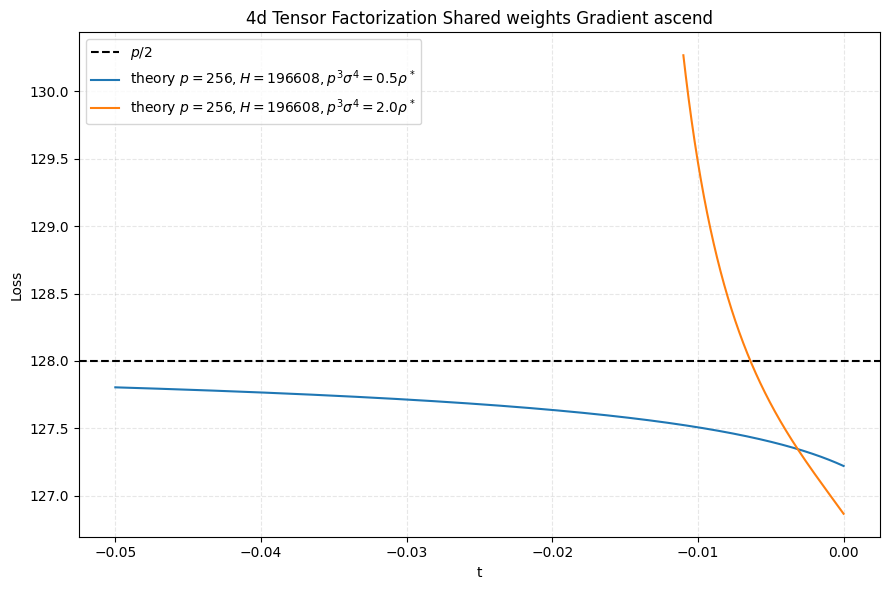

In [44]:
plt.figure(figsize=(9, 6))
plt.axhline(p/2,linestyle='--',color='black',label='$p/2$')
for i in range(len(rho_list)):
    rho = rho_list[i]*p3sigma4crit
    sigma2 = (rho/p**3)**0.5
    T = sigma2
    t_max = -t_max_list[i]
    t_arr = np.linspace(0,t_max,1000)
    loss_theory = L_ascent(t_arr,H,p,sigma2,T)
    plt.plot(t_arr,loss_theory,label=f'theory $p={p},H={H},p^3 \\sigma^4 = {rho_list[i]} \\rho^*$')


#plt.ylim(-loss_curves[0].min()+p/2,-loss_curves[0].max()+p/2)
#plt.yscale('log')
#plt.xscale('log')
plt.xlabel('t')
plt.ylabel('Loss')
plt.legend()
plt.title(f'4d Tensor Factorization Shared weights Gradient ascent')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
loss_hist_list = []
t_arr_neg_list = []

num_iters_neg = 50
batch_size = int(2**20)
for i in range(len(rho_list)):
    rho = rho_list[i]*p3sigma4crit
    sigma2 = (rho/p**3)**0.5
    T = sigma2
    t_max_neg = -t_max_list[i]
    
    # ascent (negative time)
    u,loss_hist,t_arr = train_tensor4_reconstruction_gd(p,H,sigma2,T,num_iters_neg,batch_size,t_max_neg,no_target=False)
    loss_hist_list.append(loss_hist)
    t_arr_neg_list.append(t_arr)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

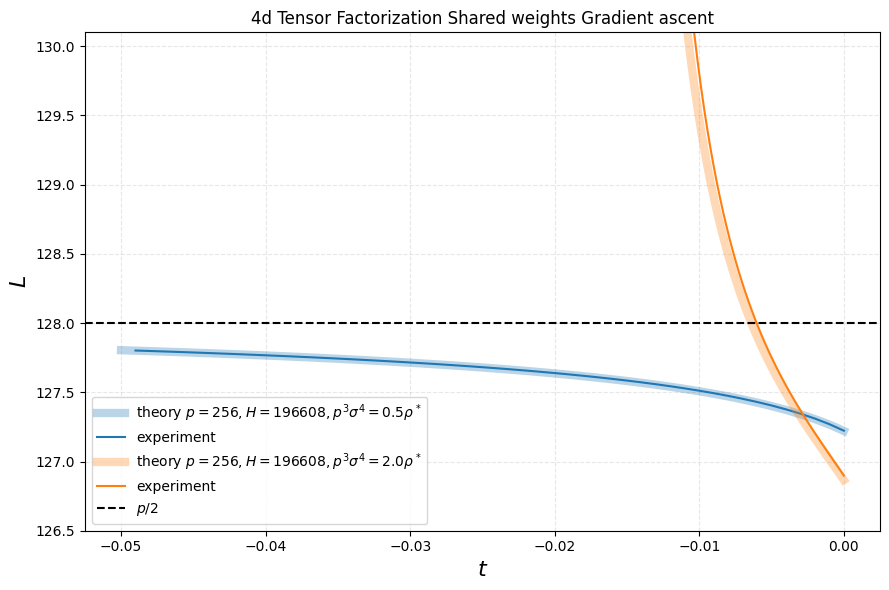

In [51]:
plt.figure(figsize=(9, 6))

for i in range(len(loss_hist_list)):
    rho = rho_list[i]*p3sigma4crit
    sigma2 = (rho/p**3)**0.5
    T = sigma2
    t_max = -t_max_list[i]
    t_arr = np.linspace(0,t_max,100)
    loss_theory = L_ascent(t_arr,H,p,sigma2,T)
    line, = plt.plot(t_arr,loss_theory,label=f'theory $p={p},H={H},p^3 \\sigma^4 = {rho_list[i]} \\rho^*$',linewidth=6,alpha=0.3)
    plt.plot(t_arr_neg_list[i],loss_hist_list[i],color=line.get_color(),label='experiment')

plt.ylim(126.5,130.1)
plt.axhline(p/2,linestyle='--',color='black',label='$p/2$')
# Axes, legend, etc.
# plt.yscale('log')
# plt.xscale('log')
plt.xlabel('$t$',fontsize=16)
plt.ylabel('$L$',fontsize=16)
plt.legend(loc='lower left')
plt.title(
    f'4d Tensor Factorization Shared weights Gradient ascent'
)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
np.save('loss_hist_list.npy',np.array(loss_hist_list))
np.save('t_arr_neg_list.npy',np.array(t_arr_neg_list))